Лабораторна робота 4  
"Класифікація"  

Мета роботи: Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic. Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("train.csv")
display(df.head())
print("Розмір таблиці:", df.shape)
print("Загальна інформація про дані:")
df.info()
print("Кількість пропущених значень у кожній колонці:")
display(df.isnull().sum())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Розмір таблиці: (891, 12)
Загальна інформація про дані:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
Кількість пропущених значень у кожній колонці:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Ми завантажили датасет Titanic, вивели таблицю, розмір таблиці та загальну інформацію про ознаки. Також маємо перевірку у яких колонках є пропущені значення, щоб правильно виконати обробку даних.

In [4]:
df_processed = df.copy()
df_processed["Age"] = df_processed["Age"].fillna(df_processed["Age"].median())
df_processed["Embarked"] = df_processed["Embarked"].fillna(df_processed["Embarked"].mode()[0])
if "Cabin" in df_processed.columns:
    df_processed["Cabin"] = df_processed["Cabin"].fillna("Unknown")
df_processed["Sex"] = df_processed["Sex"].map({"male": 0, "female": 1})
df_processed["Embarked"] = df_processed["Embarked"].map({"S": 0, "C": 1, "Q": 2})
selected_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df_processed[selected_features]
y = df_processed["Survived"]
print("Ознаки, які використовуються для класифікації:")
print(selected_features)
print("Пропущені значення після обробки:")
display(X.isnull().sum())
display(X.head())

Ознаки, які використовуються для класифікації:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Пропущені значення після обробки:


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


Заповнили пропущені значення у віці медіаною, а в колонці Embarked модою. Ознаки Sex та Embarked перетворили у числовий формат, щоб модель дерева рішень могла працювати з ними коректно.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Розмір train вибірки:", X_train.shape, y_train.shape)
print("Розмір test вибірки:", X_test.shape, y_test.shape)

Розмір train вибірки: (712, 7) (712,)
Розмір test вибірки: (179, 7) (179,)


Поділили дані на навчальну та тестову вибірку. Для порівняння використовуємо stratify=y, щоб співвідношення класів у train і test залишалося подібним до початкового набору даних.

In [7]:
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
print("Глибина дерева:", tree_model.get_depth())
print("Кількість вузлів:", tree_model.tree_.node_count)

Глибина дерева: 4
Кількість вузлів: 29


Побудували класифікатор на основі дерева рішень та надали йому навчальні дані. Отримали прогноз для тестової вибірки і проаналізували характеристики моделі, зокрема глибину дерева та кількість вузлів.

In [9]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 6))
print("Precision:", round(precision_score(y_test, y_pred), 6))
print("Recall:", round(recall_score(y_test, y_pred), 6))
print("F1:", round(f1_score(y_test, y_pred), 6))

Accuracy: 0.787709
Precision: 0.860465
Recall: 0.536232
F1: 0.660714


Обчислили потрібні метрики якості класифікації. 
Accuracy демонструє загальну частку правильних відповідей моделі, 
а Precision, Recall і F1-score дають розуміння того, як добре модель розпізнає пасажирів які вижили

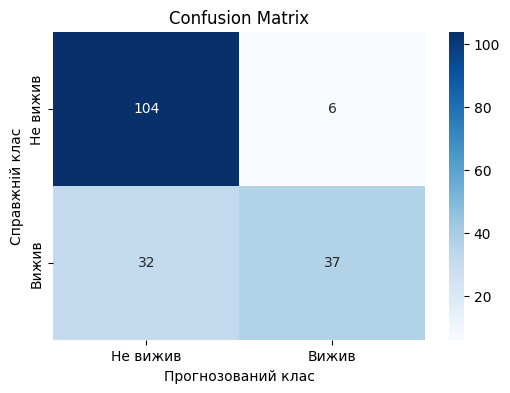

Детальний звіт класифікації:
              precision    recall  f1-score   support

    Не вижив       0.76      0.95      0.85       110
       Вижив       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Не вижив", "Вижив"],
            yticklabels=["Не вижив", "Вижив"])
plt.title("Confusion Matrix")
plt.xlabel("Прогнозований клас")
plt.ylabel("Справжній клас")
plt.show()
print("Детальний звіт класифікації:")
print(classification_report(y_test, y_pred, target_names=["Не вижив", "Вижив"]))

CM показує, скільки об'єктів було класифіковано правильно та де саме модель помиляється, а звіт класифікації дає змогу побачити precision, recall та F1-score окремо для кожного класу. Бачимо у матриці, що False Positive = 6, тобто модель повважала їх живими, хоча насправді воно не так. А також False Negative = 32, ситуація навпаки. Тобто модель помиляється, але частіше відповідала правильно.

In [17]:
class_balance = y.value_counts().sort_index()
class_balance_percent = y.value_counts(normalize=True).sort_index() * 100
balance_df = pd.DataFrame({
    "Кількість": class_balance,
    "Відсоток": class_balance_percent.round(2)
})
balance_df.index = ["Не вижив", "Вижив"]
print("Баланс класів у наборі даних:")
display(balance_df)

Баланс класів у наборі даних:


,Кількість,Відсоток
Не вижив,549,61.62
Вижив,342,38.38


Бачимо баланс класів у наборі даних. Оскільки кількість пасажирів, що не вижили більша за кількість тих, хто вижив, однієї лише метрики Accuracy недостатньо. Тобто для такого завдання більш інформативним є Precision, Recall та F1 score, бо вони краще показують якість розпізнавання менш представленого або важливого класу.

,Ознака,Важливість
1,Sex,0.576297
0,Pclass,0.195920
2,Age,0.123665
5,Fare,0.054002
6,Embarked,0.037198
3,SibSp,0.012109
4,Parch,0.000809


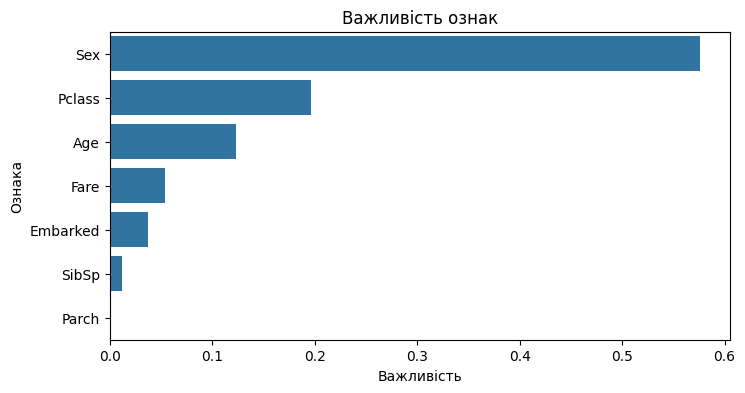

In [18]:
feature_importance = pd.DataFrame({
    "Ознака": selected_features,
    "Важливість": tree_model.feature_importances_
}).sort_values(by="Важливість", ascending=False)
display(feature_importance)
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance, x="Важливість", y="Ознака")
plt.title("Важливість ознак")
plt.xlabel("Важливість")
plt.ylabel("Ознака")
plt.show()

За допомогою feature importance визначили, які ознаки найбільше впливають на прогноз виживання пасажирів. Наприклад бачимо, що найбільше впливала стать, це є справжньою ознакою, оскільки жінкам надавали пріоритет у порятунку.

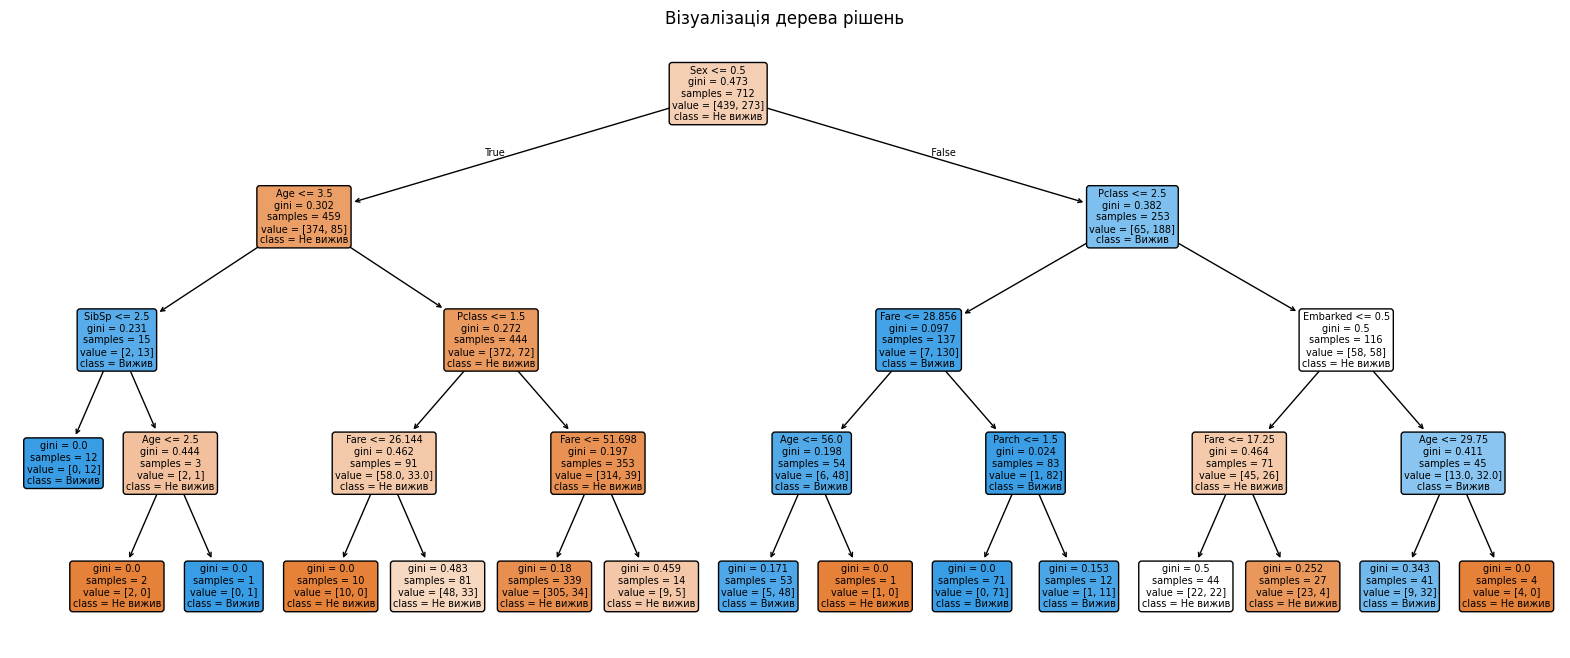

In [23]:
plt.figure(figsize=(20, 8))
plot_tree(
    tree_model,
    feature_names=selected_features,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Візуалізація дерева рішень")
plt.show()

Візуалізація дерева рішень дозволяє побачити логіку класифікації: за якими ознаками відбувається поділ, які порогові значення використовуються та як формується остаточне рішення моделі щодо виживання пасажира.
Спочатку аналізуємо за статтю, samples означає скільки об'єктів дійшло до цього вузла. value = [0,0] означає скільки [не вижило/вижило], class обирає кого більше. gini як міра хаосу, чим менше тим менше різниця класів. Також як бачимо синій означає, що вижив, а оранжевий, що ні (чим насиченіше тим більша впевненність).

У лабораторній роботі виконано класифікацію пасажирів титаніку за допомогою дерева рішень. Було проведено попередню обробку даних, усунено пропуски, перетворено категоріальні ознаки у числовий формат та виконано поділ на навчальну і тестову вибірки. Обчислено основні метрики якості класифікації, побудовано CM і класифікаційний звіт. Проаналізовано баланс класів, що показало доцільність використання не лише Accuracy, а й Precision, Recall та F1-score. Окремо визначено важливість ознак та побудовано візуалізацію дерева рішень. Це дозволило інтерпретувати модель і зробити висновок, що найбільший вплив на виживання пасажирів мають стать, клас каюти, вік та вартість квитка.